# **Wine Dataset**

Importovanie potrebných knižníc pre prácu s datasetom

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import sklearn
import sklearn.preprocessing, sklearn.cluster, sklearn.metrics
from scipy.spatial import distance_matrix
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# **Popis dát**
Odkaz na Wine dataset: [Kaggle](https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering)

---

|Atribút|Popis|
|:-------|:----------|
|Alcohol|Obsah alkoholu vo víne|
|Malic_Acid|Obsah kyseliny jablčnej|
|Ash|Obsah popola|
|Alcalinity_of_Ash|Alkalita popola|
|Magnesium|Obsah horčíka|
|Total_Phenols|Celkový obsah fenolov|
|Flavanoids|Obsah flavonoidov|
|Nonflavanoid_Phenols|Obsah neflavonoidných fenolov|
|Proanthocyanins|Obsah proantokyanidínov|
|Color_Intensity|Intenzita farby vína|
|Hue|Odtieň farby vína|
|OD280|Merný pomer absorpcie svetla na vlnovej dĺžke 280 nm|
|Proline|Obsah prolínu|



# **Načítanie Wine datasetu**



In [ ]:
df = pd.read_csv('/content/wine-clustering.csv')
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


**Zistenie dátových typov v datasete a kontrola, či sa tam nenachádzajú NaN hodnoty.**



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


Pomocou df.info() sme zistili, že všetky atribúty majú číselný typ, čo je vhodné pre clustering. Taktiež sme zistili, že dataset neobsahuje žiadne hodnoty NaN, takže nie je potrebné ošetriť prázdne hodnoty pred ďalšou analýzou.

**Základné štatistické charakteristiky dát v datasete a identifikácia rozsahov hodnôt jednotlivých atribútov.**


In [ ]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Z predošlej charakteristiky datasetu si môžeme všimnúť nejaké zaujímavosti ako napríklad:

*   **obsah alkoholu** vo víne má **minimálnu hodnotu 11.03** a **maximálnu hodnotu 14.83**, čo nám udáva že väčšina vzoriek vín mala podobný obsah alkoholu, pričom priemerná hodnota alkoholu bola 13
*   **obsah prolínu** vo vzorkach mal **priemer 746.89**, čo nám udáva že väčšina vzoriek vína bola kvalitná, keďže typická hodnota prolínu v kvalitnom prírodnom víne sa pohybuje v rozsahu od 300 do 1000 mg/l, avšak treba podotknúť že táto hodnota je zväčša vyššia pri červených vínach ako bielych



# **Hypotézy**



1.   Priemerný obsah alkoholu vo vínach sa pohybuje okolo 12%.
2.   Vína v vyššou intenzitou farby, majú vyšší obsah alkoholu.
3.   Priemerný obsah kyselín vo vínach je približne rovnaký naprieč vzorkami.


# **Vizualizácia dát**

Na základe predošlej analýzy datasetu sme zistili, že všetky atribúty spadajú do numerickej kategórie, a tak ich môžeme vizualizovať pomocou histogramov, čo nám taktiež umožní zvoliť si správnu metódu preprocessingu.



**Vizualizácia numerických dát**

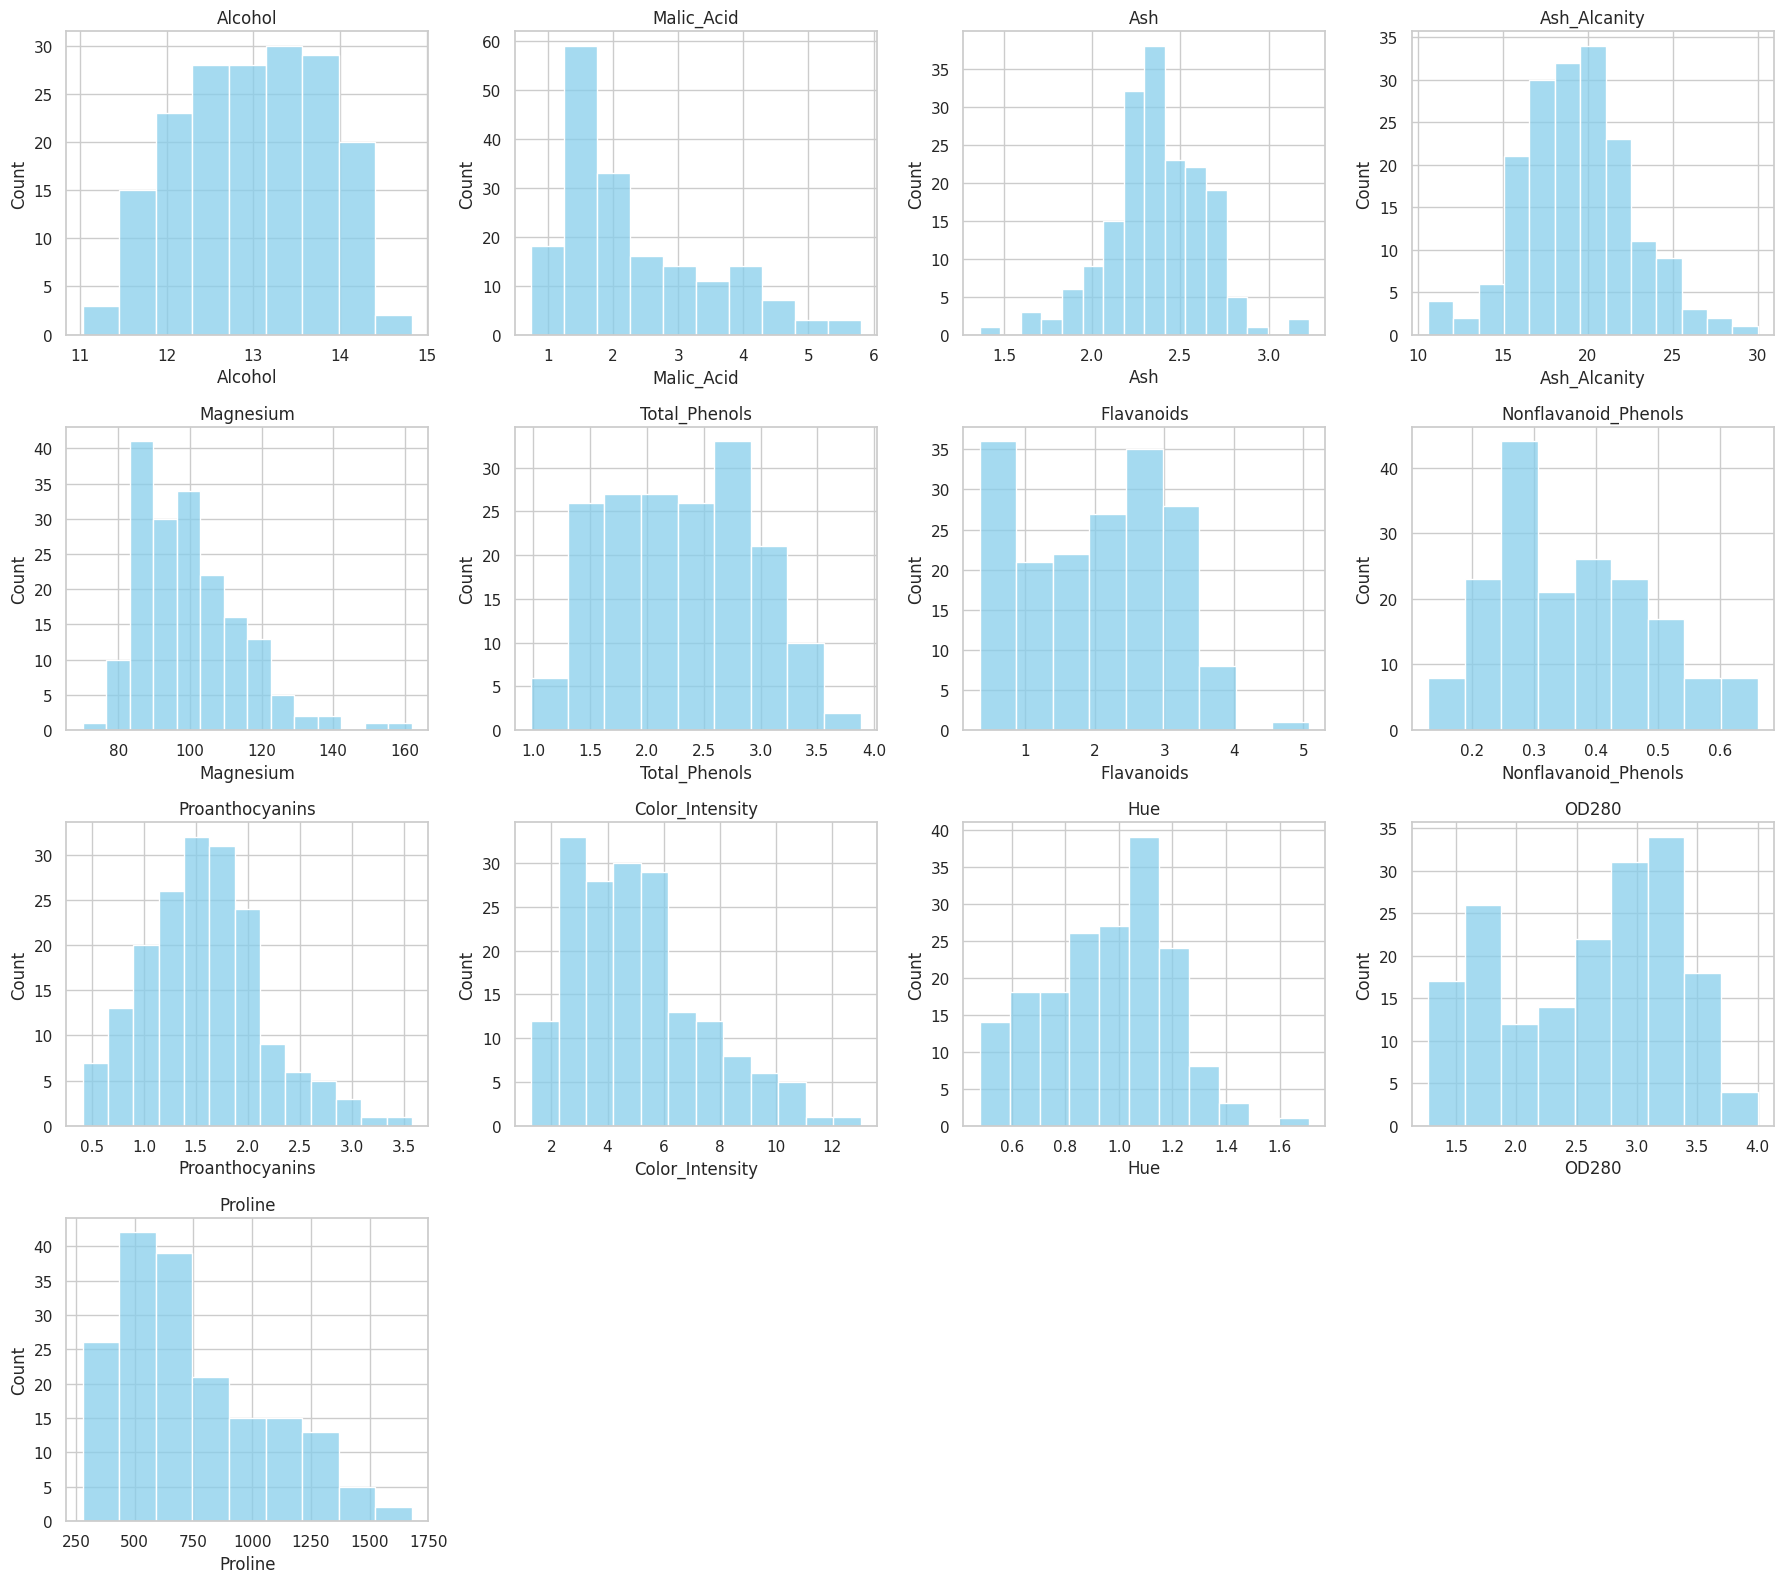

In [ ]:
df_only_numeric = df.select_dtypes(include=np.number)

n_cols = 4
n_rows = int(np.ceil(len(df_only_numeric.columns) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(df_only_numeric.columns):
    sns.histplot(data=df_only_numeric, x=column, ax=axes[i], color="skyblue").set_title(column)
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


**Vizualizácia korelačnej matice**

Text(0.5, 1.0, 'Korelácia medzi atribútmi')

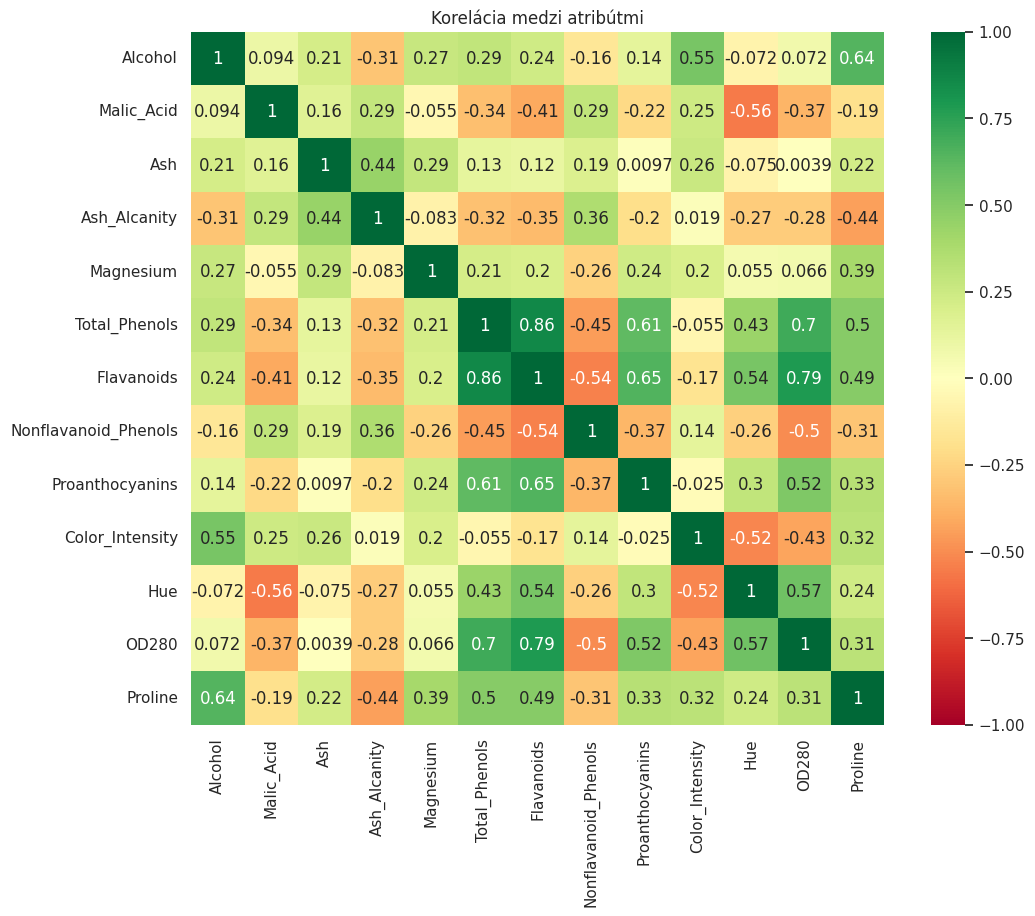

In [ ]:
df_corr = df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(df_corr, square=True, cmap='RdYlGn', vmin=-1, vmax=1, annot=True)
plt.title('Korelácia medzi atribútmi')

Na základe korelačnej matice si môžeme všimnúť zaujimavé vzťahy ako:

*   korelačný koeficient medzi flavonoidmi a celkovým obsahom fenolov je **0.86**, čo predstavuje **vysokú koreláciu**. Tento vzťah naznačuje, že vína s vyšším obsahom fenolov a flavonoidov bývajú často charakteristické výraznejšou chuťou, plnou štruktúrou a vyššou trpkosťou čo sú typické vlastnosti pre červené vína.

*   korelačný koeficient medzi alkoholom a intenzitou farby vína je **0.55**, čo predstavuje **strednú koreláciu**. To môže znamenať že vína s vyšším obsahom alkoholu majú vyššiu intenzitu farby.

*   korelačný koeficient medzi odtieňom vína a obsahom kyseliny jabĺčnej je **-0.56**, čo predstavuje **negatívnu koreláciu**. Z toho vyplíva, že vyšší obsah kyseliny jablčnej môže byť spojený s nižšími hodnotami tónu farby.






# **Spracovanie hypotéz**

**1.   Priemerný obsah alkoholu vo vínach sa pohybuje okolo 12%.**



In [ ]:
average_alcohol = df['Alcohol'].mean()

print(f"Priemerný obsah alkoholu vo vínach je: {average_alcohol:.2f}%")

Priemerný obsah alkoholu vo vínach je: 13.00%


Z toho vyplýva, že naša hypotéza sa čiastočne potvrdila, keďže sme odhadovali priemerný obsah alkoholu 12% a z datasetu vyplýva, že vypočítaný priemerný obsah je 13%.

**2.   Vína v vyššou intenzitou farby, majú vyšší obsah alkoholu.**

Korelácia medzi obsahom alkoholu a intenzitou farby je: 0.55


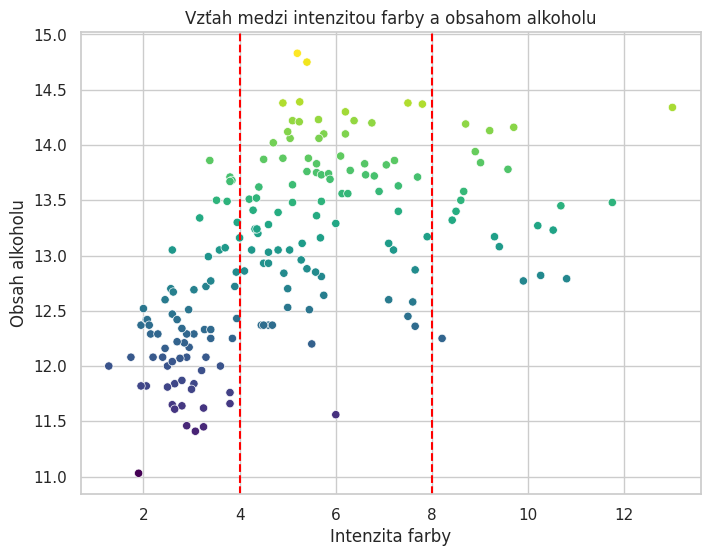

In [ ]:
correlation = df['Alcohol'].corr(df['Color_Intensity'])

print(f"Korelácia medzi obsahom alkoholu a intenzitou farby je: {correlation:.2f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Color_Intensity',
    y='Alcohol',
    data=df,
    hue='Alcohol',
    palette='viridis',
    legend=False
)


plt.axvline(x=4, color='red', linestyle='--', linewidth=1.5)
plt.axvline(x=8, color='red', linestyle='--', linewidth=1.5)

plt.title('Vzťah medzi intenzitou farby a obsahom alkoholu')
plt.xlabel('Intenzita farby')
plt.ylabel('Obsah alkoholu')
plt.show()


Táto hypotéza sa nepotvrdila, aj keď korelácia medzi týmito dvoma atribútami je 0.55, čo je pozitívna korelácia.

Z grafu nám vyplýva, že vína s intenzitou farby medzi 4 a 8, mali najvyšší priemrný podiel alkoholu.

**3.   Priemerný obsah kyselín vo vínach je približne rovnaký naprieč vzorkami**



Priemerný obsah kyseliny jablčnej vo vínach je: 2.34


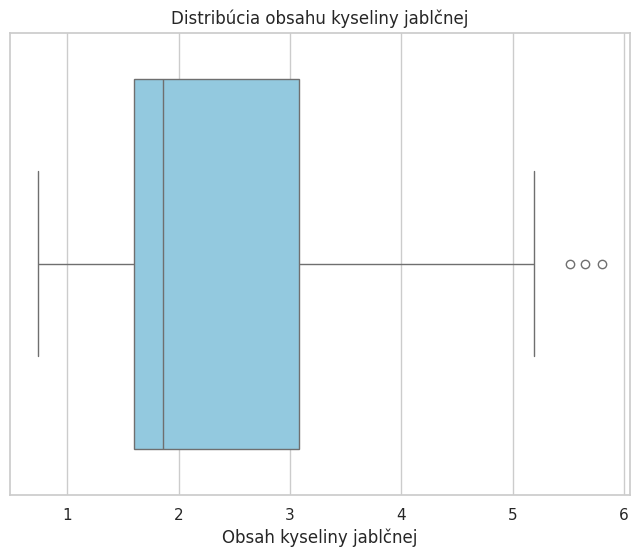

In [ ]:
average_acid = df['Malic_Acid'].mean()
print(f"Priemerný obsah kyseliny jablčnej vo vínach je: {average_acid:.2f}")

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Malic_Acid'], color='skyblue')

plt.title('Distribúcia obsahu kyseliny jablčnej')
plt.xlabel('Obsah kyseliny jablčnej')
plt.show()


Z daného grafu nám vyplýva, že väčšina hodnôt obsahu kyseliny jablčnej je sústredená v intervale medzi 1,5 a 3.3, pričom medián je blízko hodnoty 2. Týmto sa potvrdzuje, že hodnoty sú relatívne sústredené okolo priemeru.

# **Preprocessing dát**

Na základe predchádzajúcich histogramov sme sa rozhodli použiť Standard preprocessing, pretože naše dáta sú rovnomerne rozložené. Tento spôsob upraví dáta tak, aby boli lepšie pripravené na spracovanie modelmi, ktoré vyžadujú rovnakú mierku hodnôt.

In [ ]:
scaler = sklearn.preprocessing.StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

df_scaled

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


# **Clustering - K-Means**

In [ ]:
X = df_scaled.values

clustering_scores = []
for k in range(2, 11):
    clustering = sklearn.cluster.KMeans(n_clusters=k, random_state=13).fit(X)
    clustering_scores.append({
        'k': k,
        'sse': clustering.inertia_,
        'silhouette': sklearn.metrics.silhouette_score(X, clustering.labels_)
    })
df_clustering_scores = pd.DataFrame.from_dict(clustering_scores, orient='columns')
df_clustering_scores = df_clustering_scores.set_index('k')

Text(0.5, 1.0, 'Silhouette metóda')

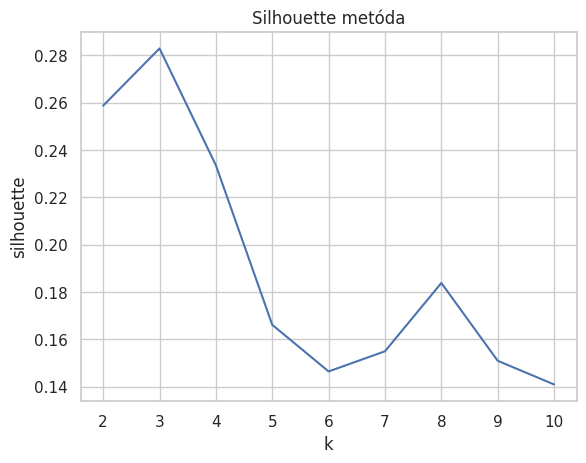

In [ ]:
sns.lineplot(data = df_clustering_scores, y='silhouette', x='k')
plt.title('Silhouette metóda')

Na základe **Elbow metódy** si z predošlého grafu určíme počet clusterov, ktorý predstavuje číslo 3.

In [ ]:
clustering = sklearn.cluster.KMeans(n_clusters=3, random_state=13)
clustering.fit(X)

KMeans(n_clusters=3, random_state=13)

Text(0.5, 1.0, 'Počet vzoriek v jednotlivých clusteroch')

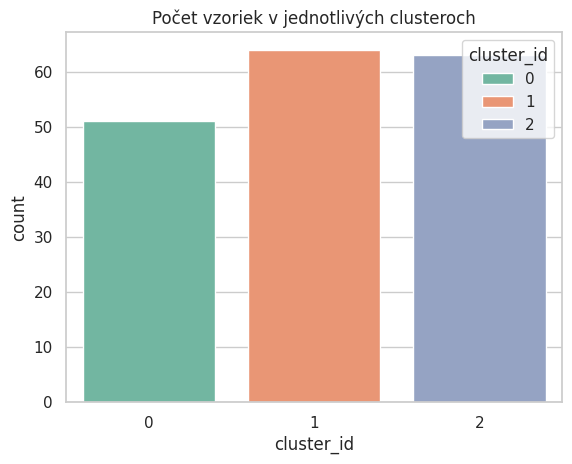

In [ ]:
df_kmeans = df.copy()
df_kmeans['cluster_id'] = clustering.labels_

sns.countplot(data=df_kmeans, x='cluster_id', hue='cluster_id', palette='Set2')
plt.title('Počet vzoriek v jednotlivých clusteroch')

In [ ]:
counts = df_kmeans['cluster_id'].value_counts()
counts_sorted = counts.sort_index()
counts_sorted

,count
cluster_id,
0,51
1,64
2,63


Vo výsledných 3 clusteroch si môžeme všimnúť, že je počet hodnôt rovnomerne rozložený, čo môže nasvedčovať tomu, že sa nám clustering vydaril.

In [ ]:
df_kmeans

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster_id
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,0
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,0
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,0
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,0


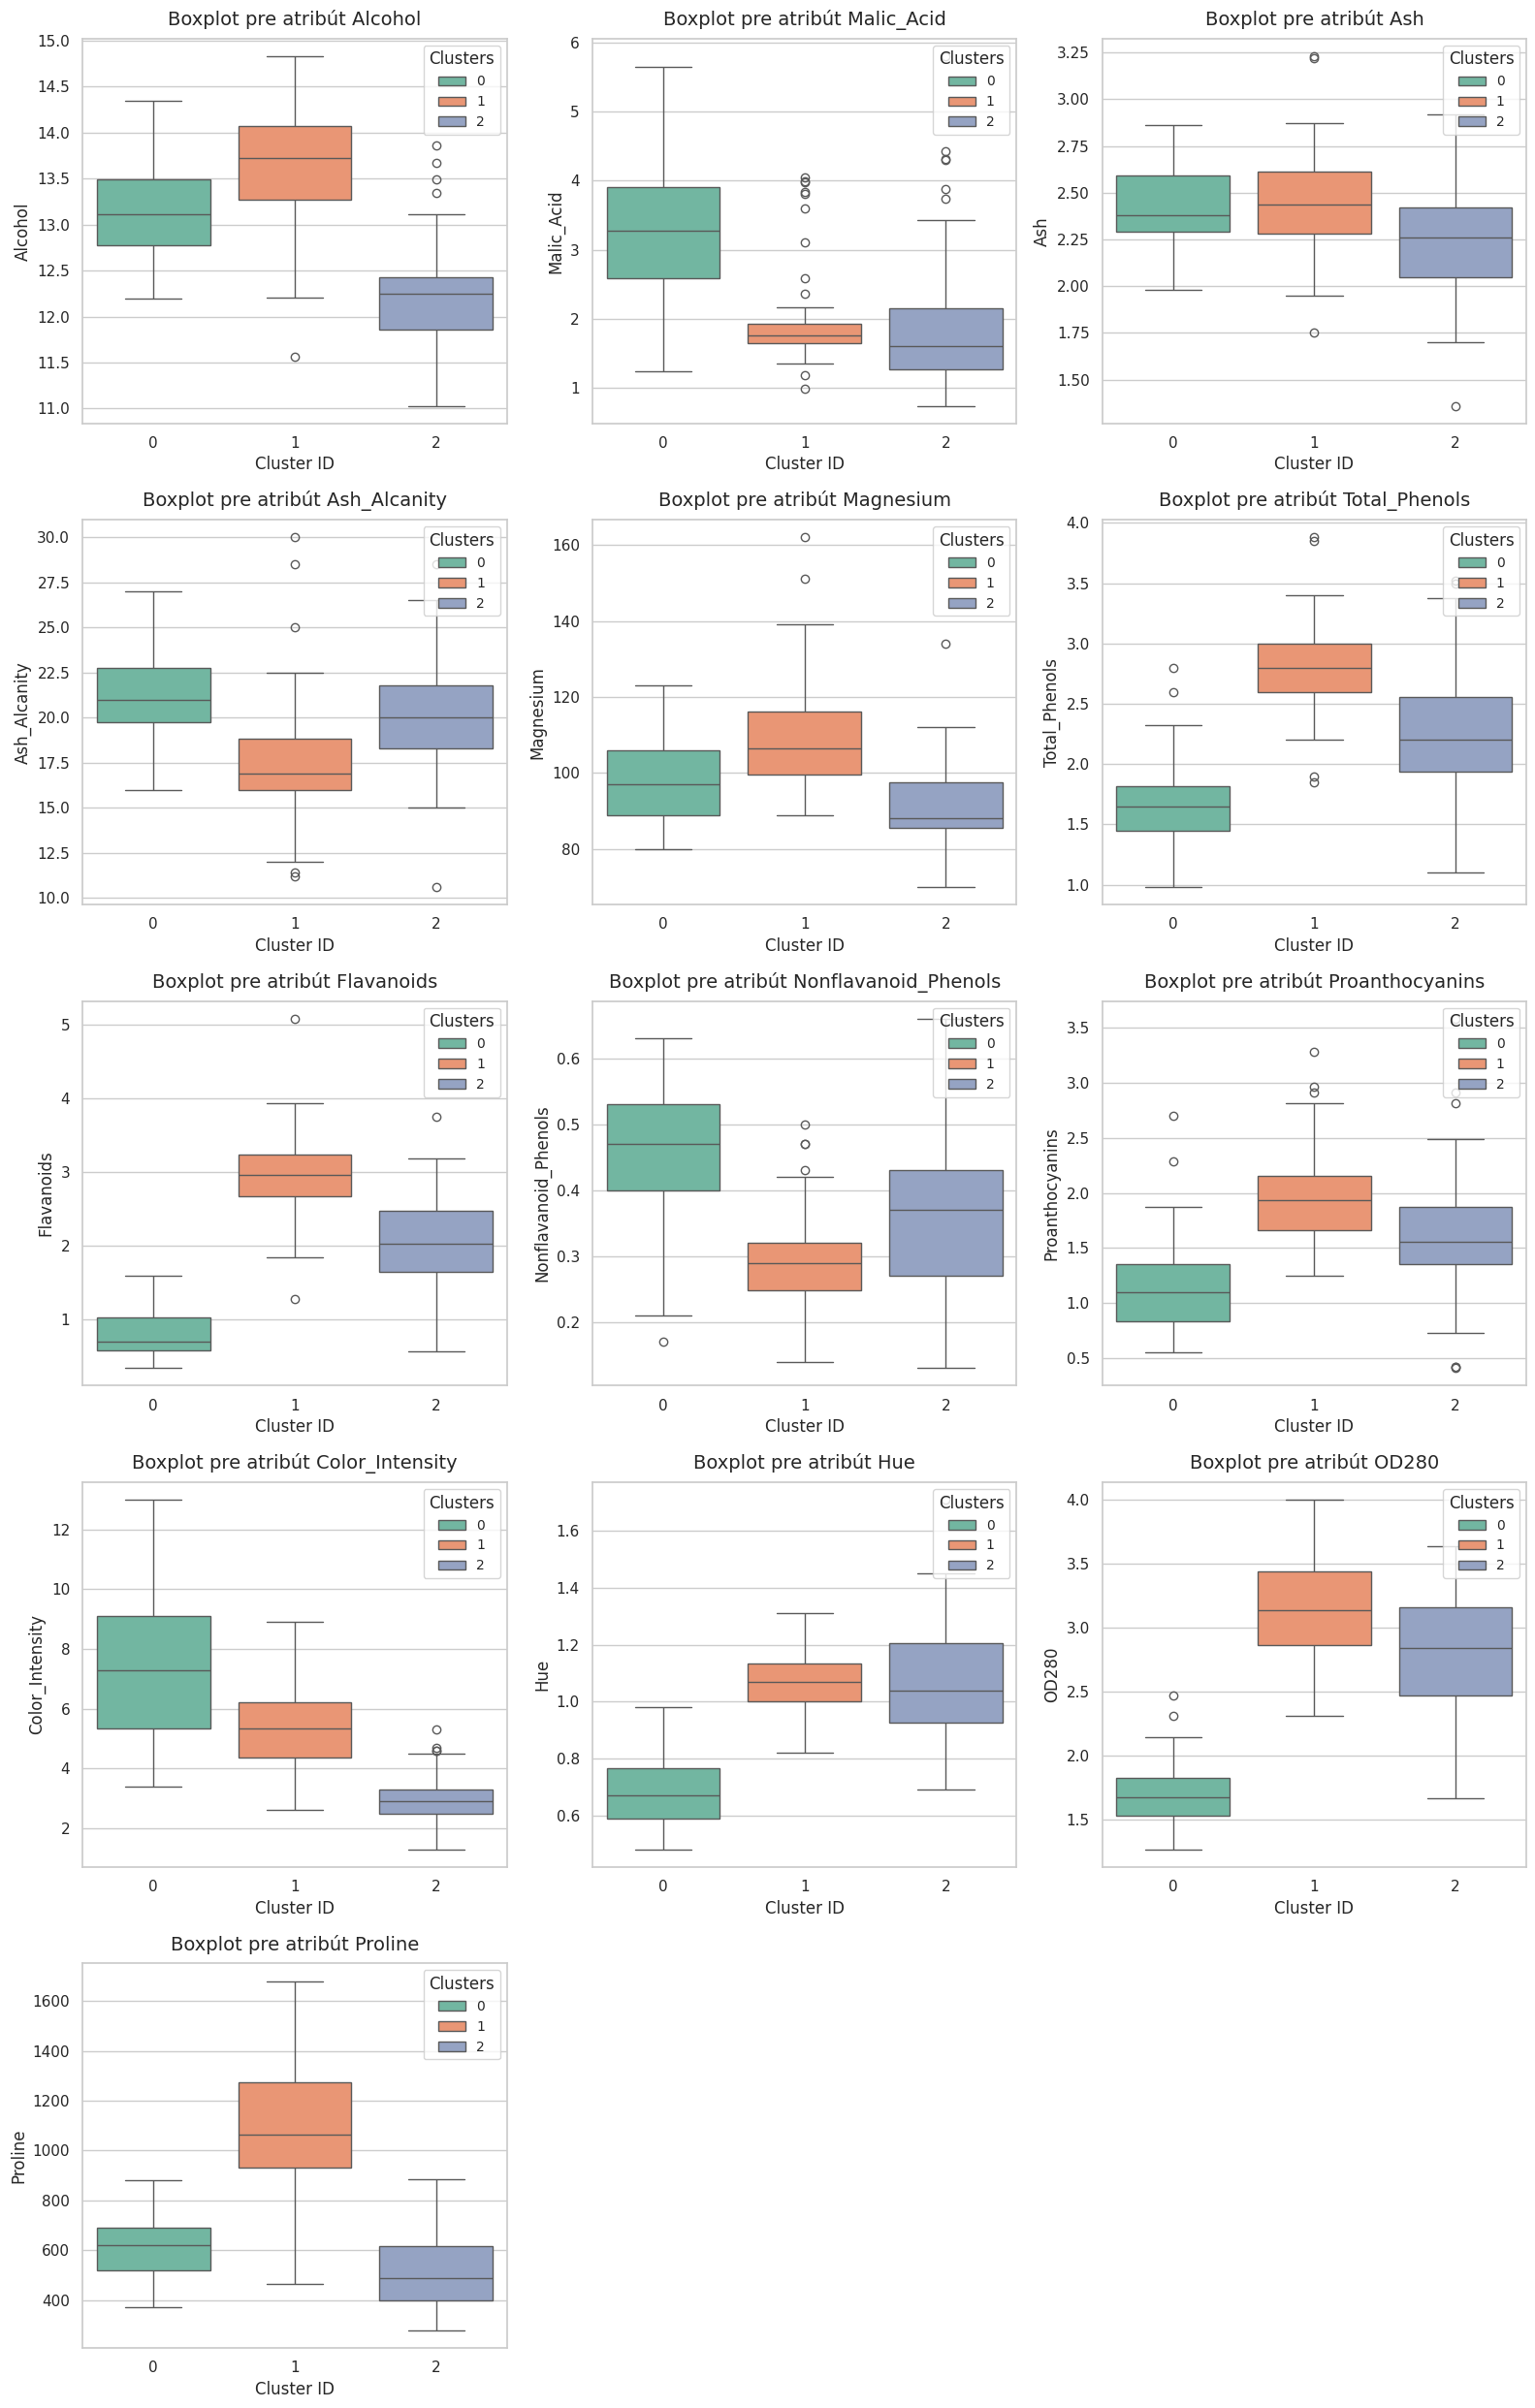

In [ ]:
n_cols = 3
n_rows = (len(df_kmeans.columns) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))

axes = axes.flatten()

for i, col in enumerate(df_kmeans.columns):
    if col != 'cluster_id':
        sns.boxplot(data=df_kmeans, x='cluster_id', hue='cluster_id', palette='Set2', y=col, ax=axes[i])

        axes[i].legend(title='Clusters', loc='upper right', fontsize=10, title_fontsize=12)
        axes[i].set_title(f'Boxplot pre atribút {col}', fontsize=14, pad=10)
        axes[i].set_xlabel('Cluster ID', fontsize=12)
        axes[i].set_ylabel(col, fontsize=12)

for i in range(len(df_kmeans.columns) - 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


**0.Cluster**
 - Stredný obsah alkoholu.
 - Vyšší obsah kyseliny jablčnej.
 - Vyššia intenzita farby.

**1.Cluster**
 - Vyšší priemerný obsah alkoholu.
 - Nižší obsah kyseliny jablčnej.
 - Stredná intenzita farby.

**2.Cluster**
 - Nižší priemerný obsah alkoholu.
 - Nižší obsah kyseliny jablčnej.
 - Nižšia intenzita farby.


 Na základe týchto rozdielov možeme povedať že jedontlivé cluster reprezentujú odlišné typy vín.

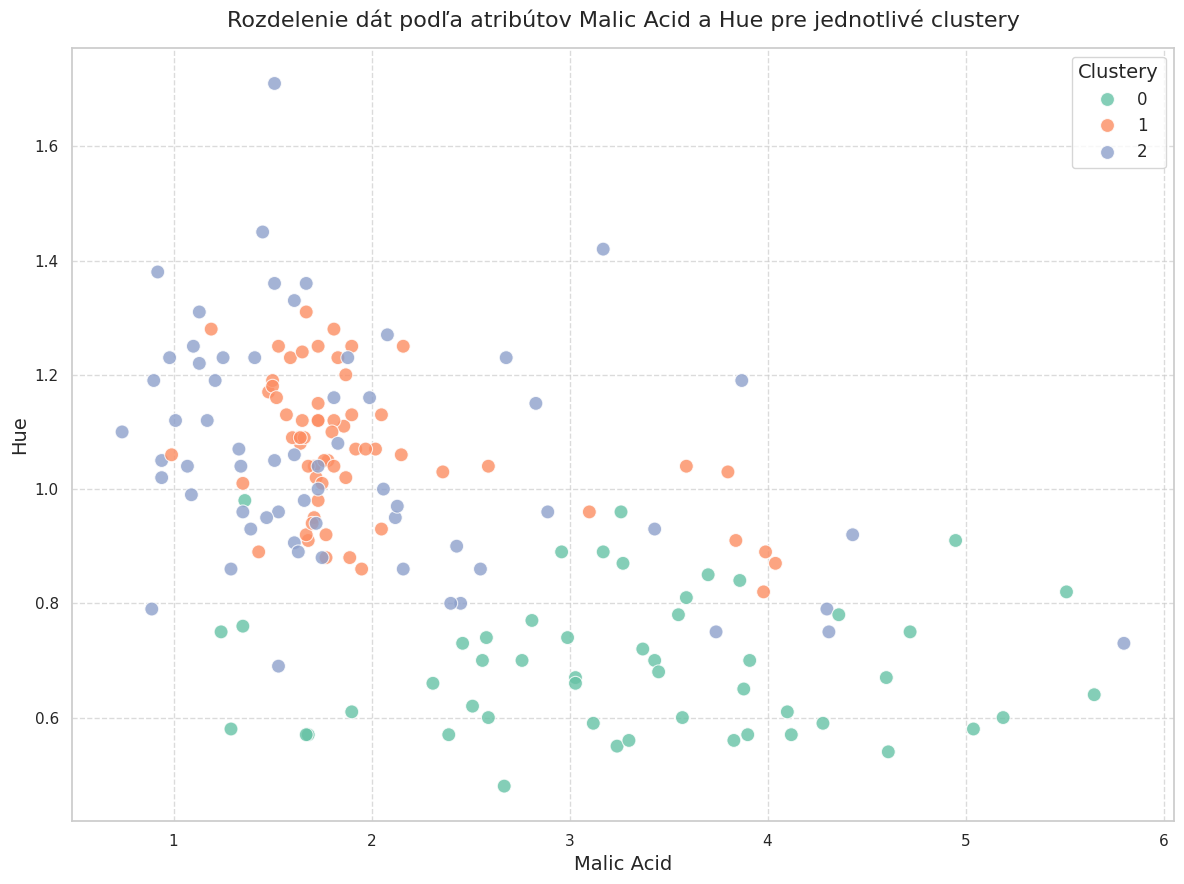

In [ ]:
plt.figure(figsize=(12, 9))

scatter = sns.scatterplot(
    data=df_kmeans,
    x='Malic_Acid',
    y='Hue',
    hue='cluster_id',
    palette='Set2',
    s=100,
    alpha=0.8
)

plt.title('Rozdelenie dát podľa atribútov Malic Acid a Hue pre jednotlivé clustery', fontsize=16, pad=15)
plt.xlabel('Malic Acid', fontsize=14)
plt.ylabel('Hue', fontsize=14)
plt.legend(title='Clustery', fontsize=12, title_fontsize=14, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

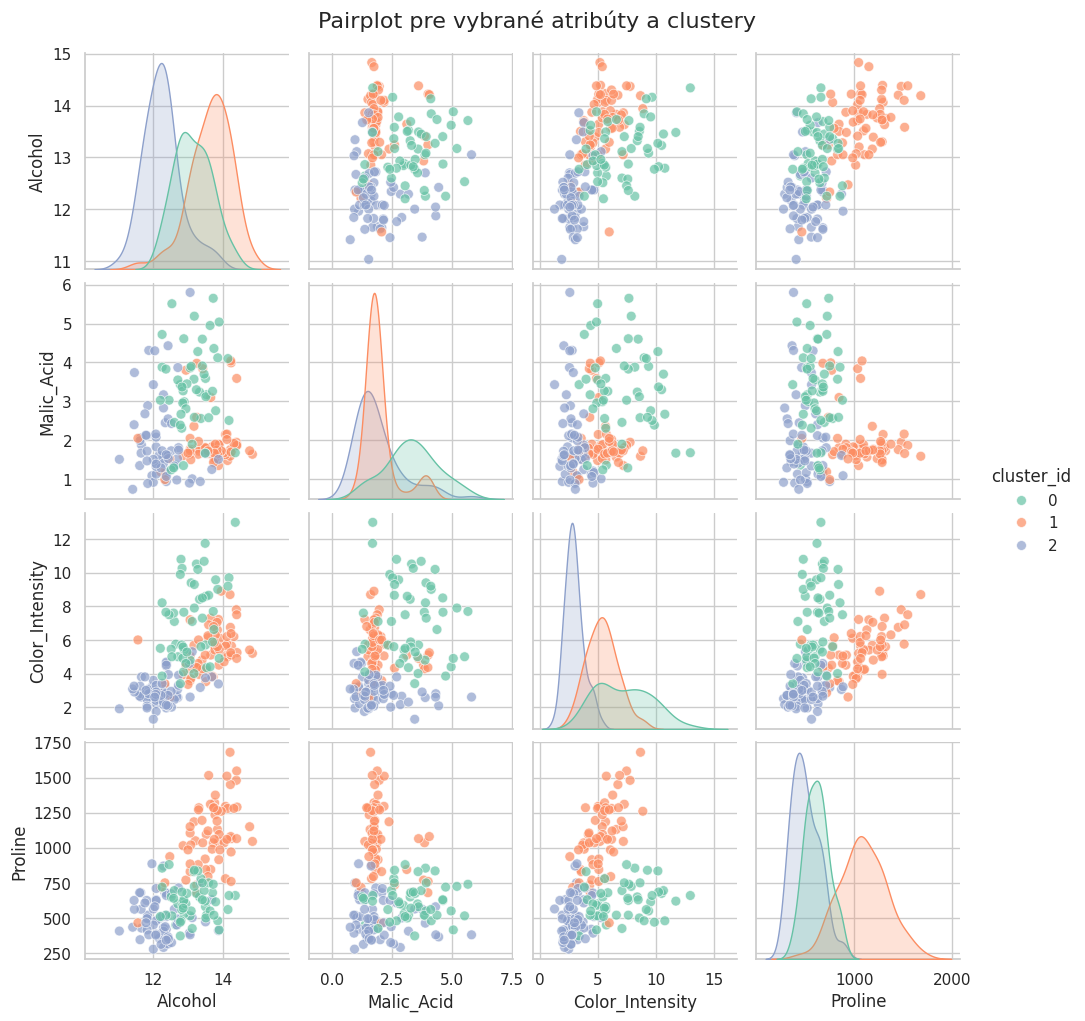

In [ ]:
plt.figure(figsize=(12, 8))
sns.pairplot(
    df_kmeans,
    hue='cluster_id',
    vars=['Alcohol', 'Malic_Acid', 'Color_Intensity', 'Proline'],
    palette='Set2',
    diag_kind='kde',
    plot_kws={'s': 50, 'alpha': 0.7}
)
plt.suptitle('Pairplot pre vybrané atribúty a clustery', y=1.02, fontsize=16)
plt.show()


# **Clustering - Agglomerative clustering**

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    # Credit to https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    plt.title('Hierarchical Clustering Dendrogram')
    dendrogram(linkage_matrix, **kwargs)
    plt.ylabel('distance')

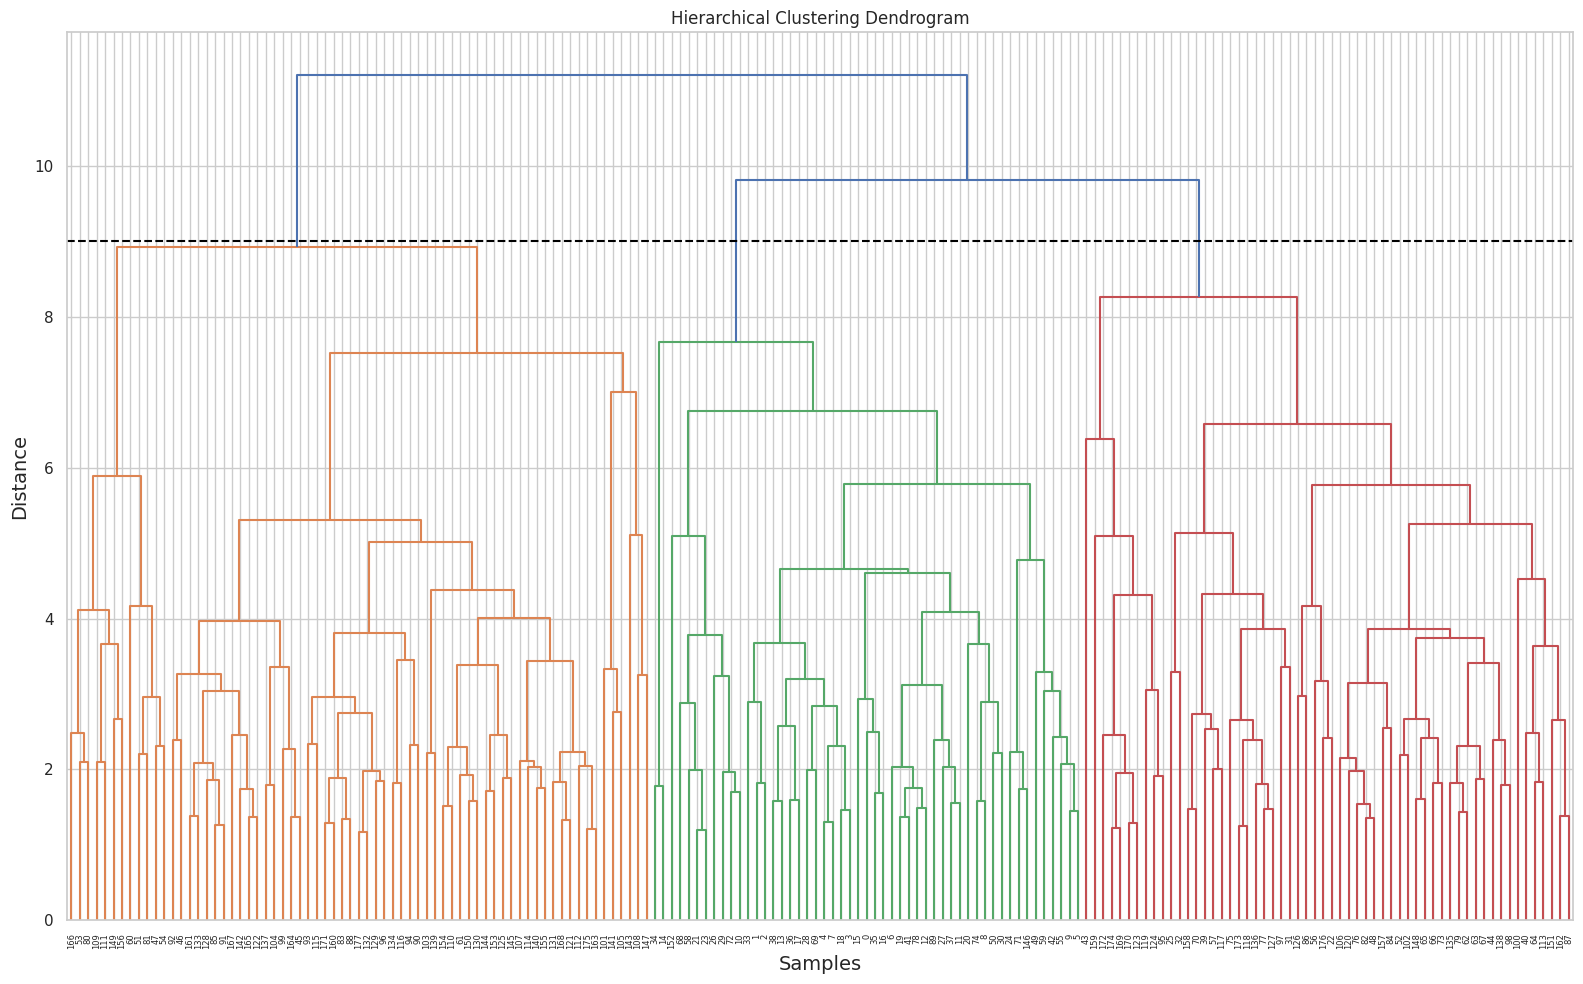

In [ ]:
clustering = AgglomerativeClustering(linkage='complete', distance_threshold=0, n_clusters=None)
clustering = clustering.fit(df_scaled)

plt.figure(figsize=(16, 10))
plot_dendrogram(clustering, labels=clustering.labels_, color_threshold=9)
plt.axhline(y=9, color='black', linestyle='--')

plt.xticks(rotation=90, fontsize=6)
plt.xlabel("Samples", fontsize=14)
plt.ylabel("Distance", fontsize=14)
plt.tight_layout()
plt.show()

Z daného dendogramu si môžeme vybrať určitý počet clusterov, vhodný pre ďalšie spracovanie dát. Vhodný počet clusterov by mohol predstavovať počet 3, tak ako je znázornené podľa čiary na distance 9.

Taktiež sme si zvolili linkage complete, keďže tento linkage nám najlepšie rovnomerne rozdelil dáta.

In [ ]:
clustering = AgglomerativeClustering(linkage='complete', distance_threshold=9, n_clusters=None)
clustering = clustering.fit(df_scaled)

<Axes: xlabel='cluster_id', ylabel='count'>

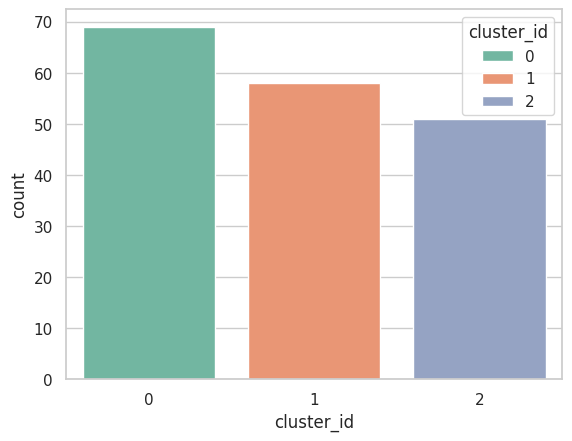

In [ ]:
df_agglomerative = df.copy()
df_agglomerative['cluster_id'] = clustering.labels_

sns.countplot(data=df_agglomerative, x='cluster_id', hue='cluster_id', palette='Set2')

In [ ]:
counts = df_agglomerative['cluster_id'].value_counts()
counts_sorted = counts.sort_index()
counts_sorted

,count
cluster_id,
0,69
1,58
2,51


In [ ]:
df_agglomerative

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster_id
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,2
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,2
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,2


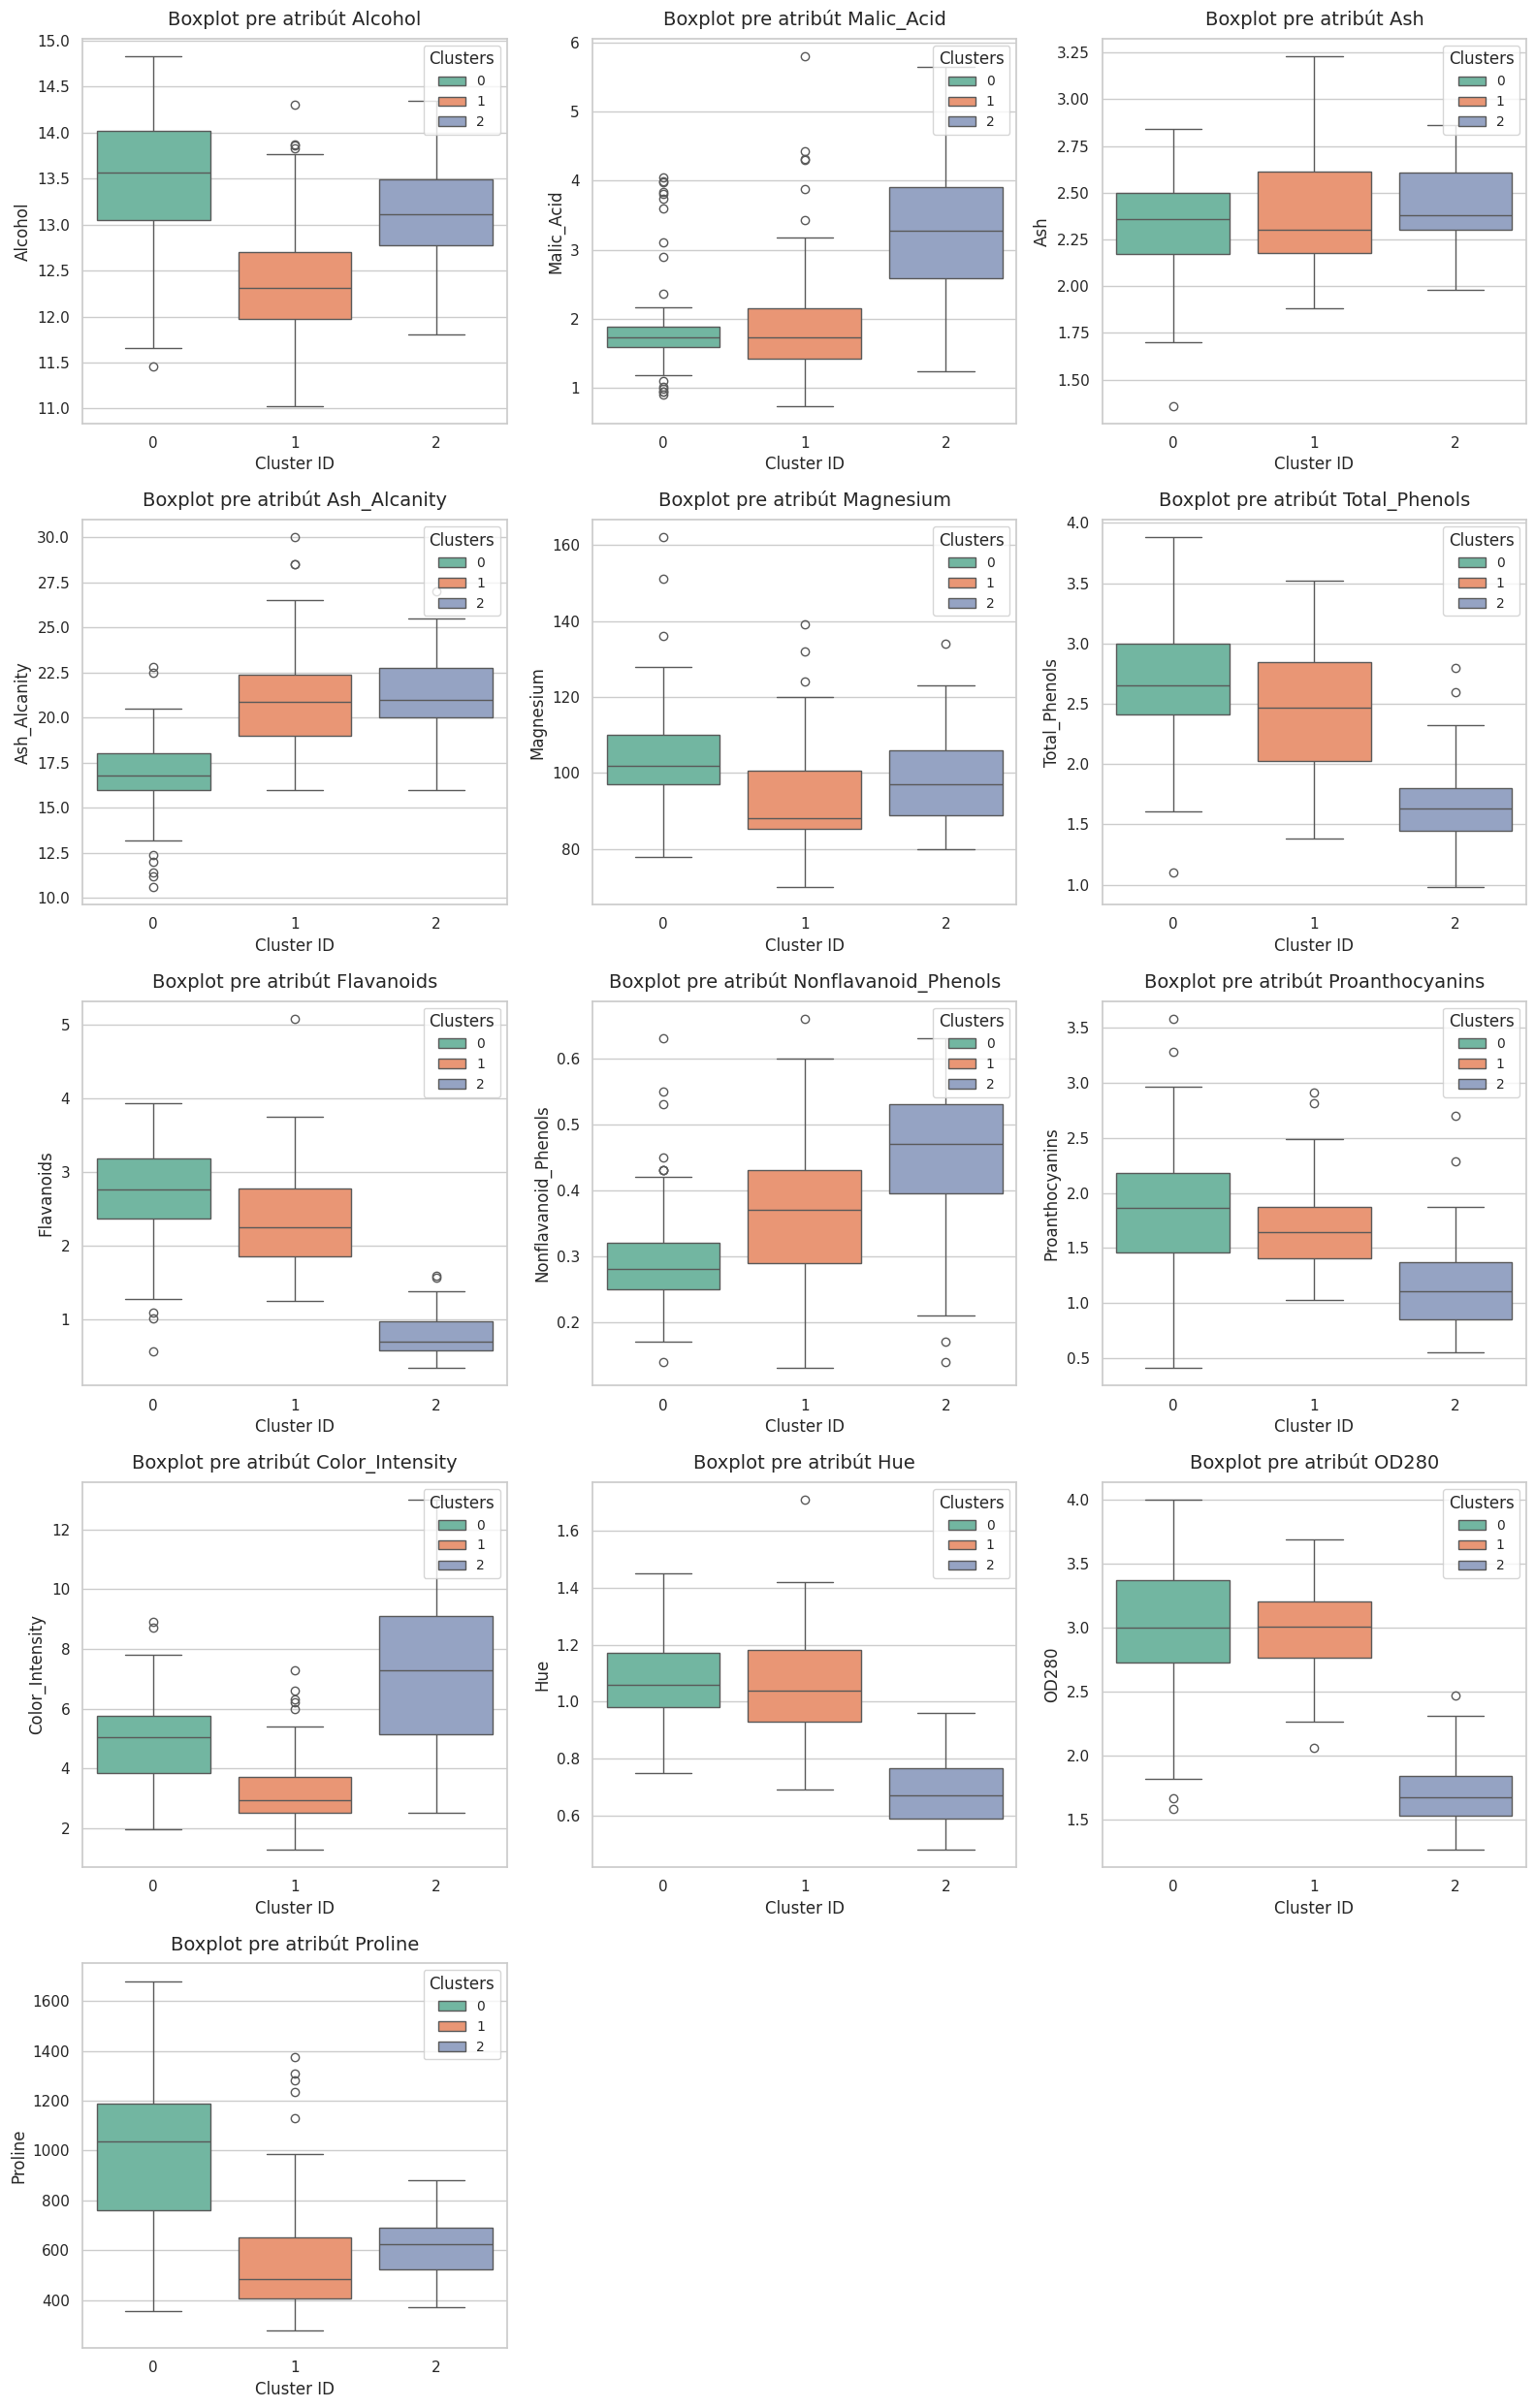

In [ ]:
n_cols = 3
n_rows = (len(df_agglomerative.columns) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))

axes = axes.flatten()

for i, col in enumerate(df_agglomerative.columns):
    if col != 'cluster_id':
        sns.boxplot(data=df_agglomerative, x='cluster_id', hue='cluster_id', palette='Set2', y=col, ax=axes[i])

        axes[i].legend(title='Clusters', loc='upper right', fontsize=10, title_fontsize=12)
        axes[i].set_title(f'Boxplot pre atribút {col}', fontsize=14, pad=10)
        axes[i].set_xlabel('Cluster ID', fontsize=12)
        axes[i].set_ylabel(col, fontsize=12)

for i in range(len(df_agglomerative.columns) - 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


**0.Cluster**
 - Vyšší priemerný obsah alkoholu.
 - Nižší obsah kyseliny jablčnej.
 - Stredná intenzita farby.

**1.Cluster**
 - Nižší priemerný obsah alkoholu.
 - Nižší obsah kyseliny jablčnej.
 - Nižšia intenzita farby.


**2.Cluster**
 - Stredný obsah alkoholu.
 - Vyšší obsah kyseliny jablčnej.
- Vyššia intenzita farby.



 Na základe týchto rozdielov možeme povedať rovnako ako pri predošlom clustrovaní, že jedontlivé cluster reprezentujú odlišné typy vín.

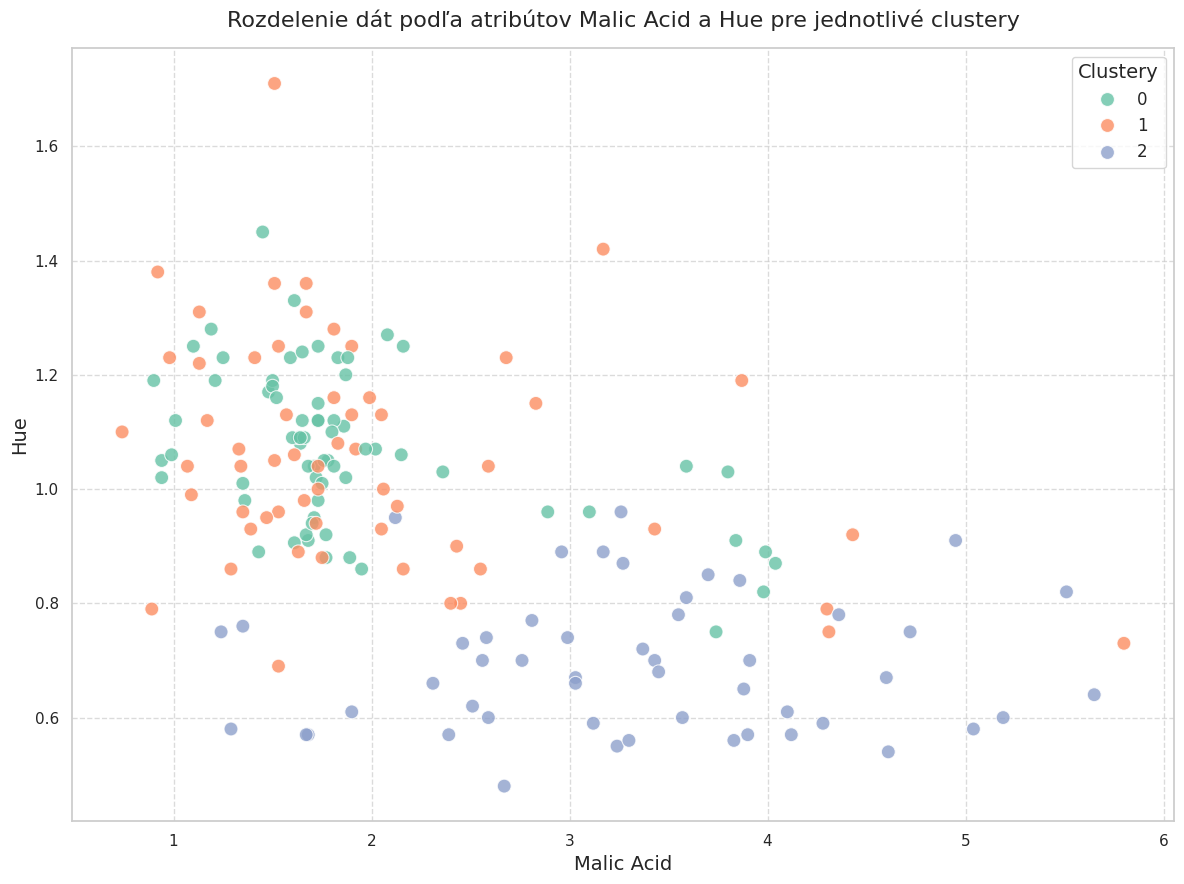

In [ ]:
plt.figure(figsize=(12, 9))

scatter = sns.scatterplot(
    data=df_agglomerative,
    x='Malic_Acid',
    y='Hue',
    hue='cluster_id',
    palette='Set2',
    s=100,
    alpha=0.8
)

plt.title('Rozdelenie dát podľa atribútov Malic Acid a Hue pre jednotlivé clustery', fontsize=16, pad=15)
plt.xlabel('Malic Acid', fontsize=14)
plt.ylabel('Hue', fontsize=14)

plt.legend(title='Clustery', fontsize=12, title_fontsize=14, loc='upper right')

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

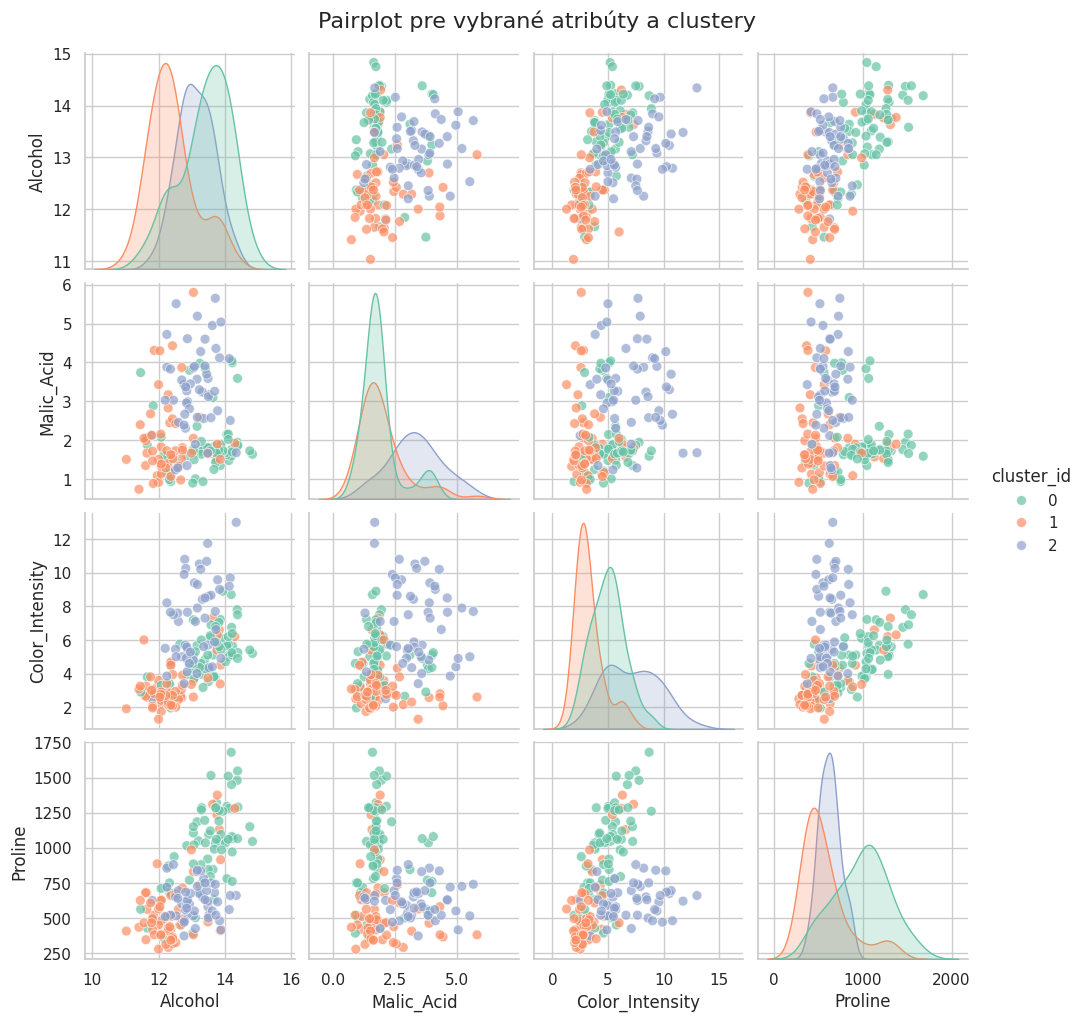

In [ ]:
plt.figure(figsize=(12, 8))
sns.pairplot(
    df_agglomerative,
    hue='cluster_id',
    vars=['Alcohol', 'Malic_Acid', 'Color_Intensity', 'Proline'],
    palette='Set2',
    diag_kind='kde',
    plot_kws={'s': 50, 'alpha': 0.7}
)
plt.suptitle('Pairplot pre vybrané atribúty a clustery', y=1.02, fontsize=16)
plt.show()



# **Zhrnutie**

Na základe analýzy datasetu som zistil viacero zaujímavých vzťahov medzi jednotlivými atribútmi. Priemerný obsah alkoholu vo vzorkách vína bol približne 13 %, čo čiastočne potvrdilo moju hypotézu, že obsah alkoholu sa pohybuje okolo 12 %. Intenzita farby vína vykazovala strednú pozitívnu koreláciu s obsahom alkoholu, čo naznačuje, že vína s vyššou intenzitou farby môžu mať o niečo vyšší obsah alkoholu. Zároveň som si všimol, že obsah kyseliny jablčnej je relatívne rovnomerne rozložený naprieč vzorkami, pričom priemerná hodnota sa pohybovala okolo 2.

Pomocou korelačnej matice som identifikoval významné vzťahy medzi niektorými atribútmi, napríklad vysokú koreláciu medzi obsahom flavonoidov a celkovým obsahom fenolov, čo potvrdzuje, že tieto látky spolu úzko súvisia. Naopak, negatívna korelácia medzi odtieňom vína a obsahom kyseliny jablčnej naznačuje, že vyšší obsah kyseliny môže byť spojený s nižšími hodnotami tónu farby.

Clustering pomocou metódy K-Means a aglomeračného klastrovania mi umožnil rozdeliť vzorky do klastrov, pričom výsledky ukázali rovnomerné rozdelenie dát.